#  Policy Gradients

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Саттон Р. С., Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* Лю Ю. (Х.) Обучение с подкреплением на PyTorch: сборник рецептов / пер. с англ. А. А. Слинкина. – М.: ДМК Пресс, 2020
* https://www.youtube.com/watch?v=_x0ASf9jV9U&ab_channel=sim0nsays
* https://karpathy.github.io/2016/05/31/rl/
* https://neerc.ifmo.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_policy_gradient_%D0%B8_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B0%D1%81%D0%B8%D0%BD%D1%85%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%B0-%D0%BA%D1%80%D0%B8%D1%82%D0%B8%D0%BA%D0%B0
* https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html
* https://huggingface.co/learn/deep-rl-course/unit4/introduction
* https://lilianweng.github.io/posts/2018-04-08-policy-gradient/#:~:text=The%20goal%20of%20reinforcement%20learning,and%20optimizing%20the%20policy%20directly.

## Задачи для совместного разбора

1\. Рассмотрите основные шаги по формированию обучающей выборки для использования алгоритмов Policy Gradients.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите классы `Policy` для реализации модели политики и `Trainer` для реализации процесса обучения модели при помощи алгоритма REINFORCE. Настройте агента для игры в окружении `CartPole-v1`. Визуализируйте динамику значений награды на эпизод в процессе обучения. Сыграйте эпизод, используя обученного агента, и убедитесь, что агент выучивается, как стабилизировать шест.

$$L_{PG} = -\sum_{i}{R_i\log{p(a_i|s_i)}}$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.


- [ ] Проверено на семинаре

In [20]:
import os
import gc
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from collections import deque
import gymnasium as gym
import random
import matplotlib.pyplot as plt

device = 'cuda'

In [21]:

class PolicyNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.model(state)

    def get_action(self, state):
        action_probs = self.forward(state)
        dist = torch.distributions.Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


class Trainer:
    def __init__(self, env, policy, optimizer, gamma=0.99):
        self.env = env
        self.policy = policy
        self.optimizer = optimizer
        self.gamma = gamma

    def compute_returns(self, rewards):
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns)
        return (returns - returns.mean()) / (returns.std() + 1e-8)

    def train(self, num_episodes):
        all_rewards = []
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            log_probs = []
            rewards = []

            while True:
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action, log_prob = self.policy.get_action(state_tensor)
                next_state, reward, done, truncation, _ = self.env.step(action)

                log_probs.append(log_prob)
                rewards.append(reward)
                state = next_state

                if done or truncation:
                    returns = self.compute_returns(rewards)
                    loss = -(torch.stack(log_probs) * returns).sum()

                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                    break

            total_reward = sum(rewards)
            all_rewards.append(total_reward)
            print(f"Episode {episode + 1}, Reward: {total_reward}")

        return all_rewards

    def test(self, num_episodes):
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False

            while not done:
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action_probs = self.policy(state_tensor)
                action = torch.argmax(action_probs, dim=1).item()
                state, reward, done, truncation, _ = self.env.step(action)
                total_reward += reward

            print(f"Test Episode {episode + 1}, Reward: {total_reward}")
    def train_batch(self, num_episodes, batch_size):
        all_rewards = []
        batch_rewards = []
        batch_log_probs = []

        for episode in range(num_episodes):
            state, _ = self.env.reset()
            log_probs = []
            rewards = []

            while True:
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action, log_prob = self.policy.get_action(state_tensor)
                next_state, reward, done, truncation, _ = self.env.step(action)

                log_probs.append(log_prob)
                rewards.append(reward)
                state = next_state

                if done or truncation:
                    batch_rewards.append(rewards)
                    batch_log_probs.append(log_probs)
                    all_rewards.append(sum(rewards))
                    break

            if (episode + 1) % batch_size == 0:
                all_returns = []
                all_log_probs = []

                for rewards, log_probs in zip(batch_rewards, batch_log_probs):
                    returns = self.compute_returns(rewards)
                    all_returns.extend(returns.unsqueeze(-1))  # Преобразуем в размерность [1]
                    all_log_probs.extend(log_probs)

                # Переносим на устройство
                all_returns = torch.cat(all_returns).to(device)
                all_log_probs = torch.stack(all_log_probs).to(device)

                # Вычисление функции потерь
                loss = -(all_log_probs * all_returns).sum()
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                # Очистка батчей
                batch_rewards = []
                batch_log_probs = []

            if episode % 10 == 0:
                print(f"Episode {episode + 1}, Reward: {all_rewards[-1]}")

        return all_rewards


<p class="task" id="2"></p>

2\. Повторите решение задачи 1, делая шаг обучения не после одного эпизода, а по результату прогонов нескольких эпизодов. Обратите внимание, что после обновления весов модели все старые данные для обучения становятся неактуальными и должны быть удалены.

- [ ] Проверено на семинаре

Episode 1, Reward: 18.0
Episode 11, Reward: 32.0
Episode 21, Reward: 25.0
Episode 31, Reward: 12.0
Episode 41, Reward: 17.0
Episode 51, Reward: 12.0
Episode 61, Reward: 16.0
Episode 71, Reward: 16.0
Episode 81, Reward: 20.0
Episode 91, Reward: 50.0
Episode 101, Reward: 31.0
Episode 111, Reward: 14.0
Episode 121, Reward: 40.0
Episode 131, Reward: 18.0
Episode 141, Reward: 41.0
Episode 151, Reward: 27.0
Episode 161, Reward: 10.0
Episode 171, Reward: 13.0
Episode 181, Reward: 11.0
Episode 191, Reward: 20.0
Episode 201, Reward: 10.0
Episode 211, Reward: 26.0
Episode 221, Reward: 13.0
Episode 231, Reward: 35.0
Episode 241, Reward: 13.0
Episode 251, Reward: 14.0
Episode 261, Reward: 16.0
Episode 271, Reward: 11.0
Episode 281, Reward: 20.0
Episode 291, Reward: 11.0
Episode 301, Reward: 20.0
Episode 311, Reward: 15.0
Episode 321, Reward: 15.0
Episode 331, Reward: 13.0
Episode 341, Reward: 39.0
Episode 351, Reward: 12.0
Episode 361, Reward: 31.0
Episode 371, Reward: 33.0
Episode 381, Reward: 36

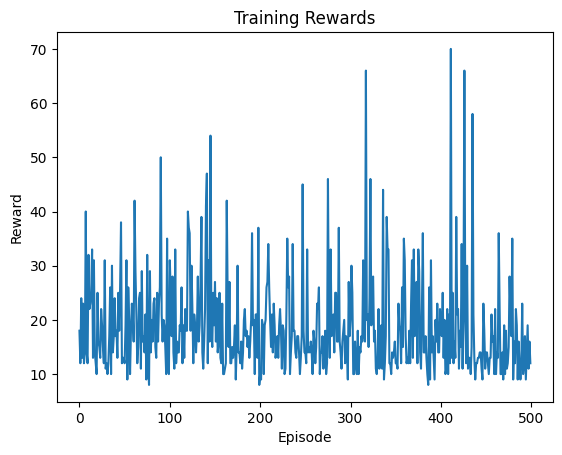

In [22]:
env = gym.make("CartPole-v1")
input_size = env.observation_space.shape[0]
output_size = env.action_space.n
hidden_size = 128

policy = PolicyNetwork(input_size, hidden_size, output_size).to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=0.001)

trainer = Trainer(env, policy, optimizer, gamma=0.99)

# Обучение
rewards = trainer.train_batch(num_episodes=500, batch_size=64)

# Тестирование
trainer.test(num_episodes=5)

# Визуализация наград
import matplotlib.pyplot as plt
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards")
plt.show()

<p class="task" id="3"></p>

3\. Повторите решение задачи 1, реализовав алгоритм REINFONCE с baseline.

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи двух независимых сетей. Сеть для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Сеть для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Настройка весов обеих моделей происходит после каждого эпизода.

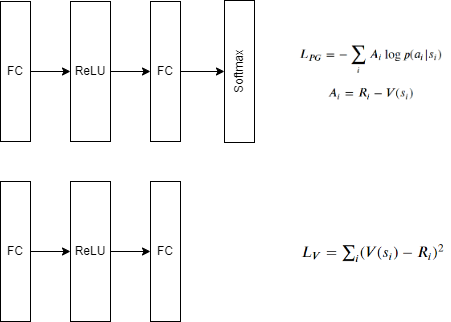

- [ ] Проверено на семинаре

In [26]:
class PolicyWithBaseline(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.policy = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Softmax(dim=-1)
        )
        self.value = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state):
        action_probs = self.policy(state)
        value = self.value(state)
        return action_probs, value


class TrainerWithBaseline:
    def __init__(self, env, policy_net, optimizer, gamma=0.99):
        self.env = env
        self.policy_net = policy_net
        self.optimizer = optimizer
        self.gamma = gamma

    def compute_returns(self, rewards):
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns)
        return (returns - returns.mean()) / (returns.std() + 1e-8)

    def train(self, num_episodes):
        all_rewards = []
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            log_probs = []
            values = []
            rewards = []

            while True:
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action_probs, value = self.policy_net(state_tensor)
                dist = torch.distributions.Categorical(action_probs)
                action = dist.sample()
                log_prob = dist.log_prob(action)

                next_state, reward, done, truncation, _ = self.env.step(action.item())
                log_probs.append(log_prob)
                values.append(value)
                rewards.append(reward)
                state = next_state

                if done or truncation:
                    returns = self.compute_returns(rewards).cuda()
                    log_probs = torch.stack(log_probs)
                    values = torch.cat(values).squeeze(-1).cuda()
                    advantages = returns.cuda() - values

                    # Функция потерь
                    policy_loss = -(log_probs * advantages).sum()
                    value_loss = ((values - returns) ** 2).sum()
                    loss = policy_loss + value_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                    break

            total_reward = sum(rewards)
            all_rewards.append(total_reward)
            print(f"Episode {episode + 1}, Reward: {total_reward}")

        return all_rewards


<p class="task" id="4"></p>

4\. Повторите решение задачи 1, реализовав алгоритм Actor-Critic

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи одной сети в двумя головами. Голова для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Голова для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Итоговая функции потерь для настройки представляет из себя сумму функций потерь для голов: $L = L_{PG} + L_{V}$.

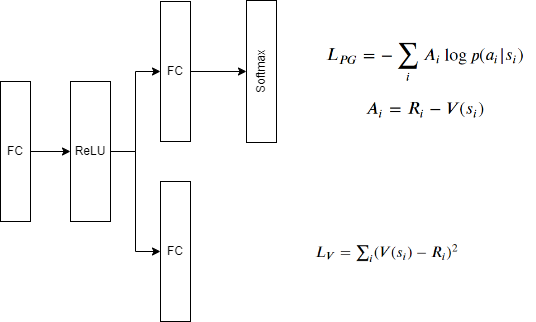

- [ ] Проверено на семинаре

In [27]:
class ActorCriticNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.common = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU()
        )
        self.policy_head = nn.Sequential(
            nn.Linear(hidden_size, output_size),
            nn.Softmax(dim=-1)
        )
        self.value_head = nn.Linear(hidden_size, 1)

    def forward(self, state):
        common_out = self.common(state)
        action_probs = self.policy_head(common_out)
        value = self.value_head(common_out)
        return action_probs, value


class ActorCriticTrainer:
    def __init__(self, env, ac_net, optimizer, gamma=0.99):
        self.env = env
        self.ac_net = ac_net
        self.optimizer = optimizer
        self.gamma = gamma

    def compute_returns(self, rewards):
        R = 0
        returns = []
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns)
        return (returns - returns.mean()) / (returns.std() + 1e-8)

    def train(self, num_episodes):
        all_rewards = []
        for episode in range(num_episodes):
            state, _ = self.env.reset()
            log_probs = []
            values = []
            rewards = []

            while True:
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action_probs, value = self.ac_net(state_tensor)
                dist = torch.distributions.Categorical(action_probs)
                action = dist.sample()
                log_prob = dist.log_prob(action)

                next_state, reward, done, truncation, _ = self.env.step(action.item())
                log_probs.append(log_prob)
                values.append(value)
                rewards.append(reward)
                state = next_state

                if done or truncation:
                    returns = (self.compute_returns(rewards)).cuda()
                    log_probs = torch.stack(log_probs)
                    values = (torch.cat(values).squeeze(-1)).cuda()
                    advantages = returns.cuda() - values

                    # Функция потерь
                    policy_loss = -(log_probs * advantages).sum()
                    value_loss = ((values.cuda() - returns.cuda()) ** 2).sum()
                    loss = policy_loss + value_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    self.optimizer.step()
                    break

            total_reward = sum(rewards)
            all_rewards.append(total_reward)
            print(f"Episode {episode + 1}, Reward: {total_reward}")

        return all_rewards


Episode 1, Reward: 9.0
Episode 2, Reward: 19.0
Episode 3, Reward: 11.0
Episode 4, Reward: 11.0
Episode 5, Reward: 23.0
Episode 6, Reward: 9.0
Episode 7, Reward: 14.0
Episode 8, Reward: 11.0
Episode 9, Reward: 17.0
Episode 10, Reward: 31.0
Episode 11, Reward: 30.0
Episode 12, Reward: 11.0
Episode 13, Reward: 13.0
Episode 14, Reward: 30.0
Episode 15, Reward: 16.0
Episode 16, Reward: 30.0
Episode 17, Reward: 17.0
Episode 18, Reward: 10.0
Episode 19, Reward: 9.0
Episode 20, Reward: 12.0
Episode 21, Reward: 15.0
Episode 22, Reward: 15.0
Episode 23, Reward: 13.0
Episode 24, Reward: 12.0
Episode 25, Reward: 15.0
Episode 26, Reward: 20.0
Episode 27, Reward: 21.0
Episode 28, Reward: 46.0
Episode 29, Reward: 15.0
Episode 30, Reward: 29.0
Episode 31, Reward: 16.0
Episode 32, Reward: 23.0
Episode 33, Reward: 25.0
Episode 34, Reward: 28.0
Episode 35, Reward: 15.0
Episode 36, Reward: 10.0
Episode 37, Reward: 50.0
Episode 38, Reward: 15.0
Episode 39, Reward: 12.0
Episode 40, Reward: 57.0
Episode 41, 

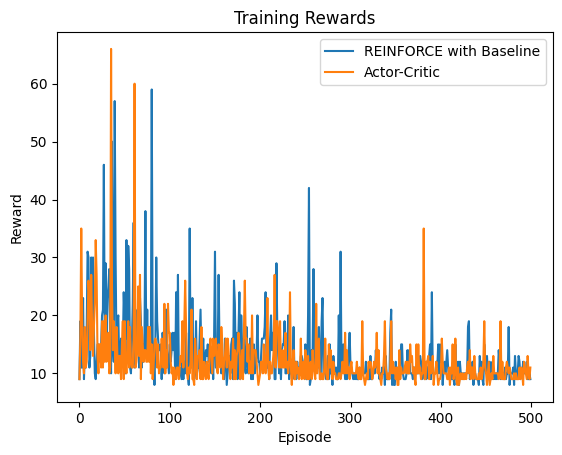

In [28]:
env = gym.make("CartPole-v1")
input_size = env.observation_space.shape[0]
output_size = env.action_space.n
hidden_size = 128

# Задание 3: REINFORCE с baseline
policy_net = PolicyWithBaseline(input_size, hidden_size, output_size).to(device)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=0.001)
trainer = TrainerWithBaseline(env, policy_net, optimizer, gamma=0.99)
rewards = trainer.train(num_episodes=500)

# Задание 4: Actor-Critic
ac_net = ActorCriticNetwork(input_size, hidden_size, output_size).to(device)
optimizer = torch.optim.Adam(ac_net.parameters(), lr=0.001)
ac_trainer = ActorCriticTrainer(env, ac_net, optimizer, gamma=0.99)
ac_rewards = ac_trainer.train(num_episodes=500)

# Визуализация наград
import matplotlib.pyplot as plt
plt.plot(rewards, label="REINFORCE with Baseline")
plt.plot(ac_rewards, label="Actor-Critic")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Rewards")
plt.legend()
plt.show()

## Обратная связь
- [ ] Хочу получить обратную связь по решению